# 05 — ML Tournament

Trains 5 regression models, picks the best one, and optimizes it via
RandomizedSearchCV with **TimeSeriesSplit** (proper cross-validation
for temporal data — no leakage).

**Input:** `data/processed/dataset_smart_campus_master.csv`
**Outputs:**
- `outputs/models/best_model.pkl`
- `outputs/models/training_columns.pkl`
- Saved test set + predictions for the next notebook


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor

DATA_PROCESSED = Path('../data/processed')
MODELS = Path('../outputs/models')
MODELS.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
sns.set_theme(style="whitegrid")


## 1. Feature engineering & cleanup

In [14]:
df_ml = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv',
                    parse_dates=['Timestamp'])

# Inspect possible sensor failures BEFORE filtering
print("🔍 Inspecting possible sensor failures (Consumo_kWh ≤ 5)...")
corruptos = df_ml[df_ml['Consumo_kWh'] <= 5]
print(f"   Found {len(corruptos)} suspicious rows.")
if len(corruptos) > 0:
    print(corruptos[['Timestamp', 'Consumo_kWh']].head())

# Extract hour-of-day feature
df_ml['Hora_del_Dia'] = df_ml['Timestamp'].dt.hour

# One-hot encode categoricals
df_ml = pd.get_dummies(df_ml, columns=['Dia_Semana', 'tipus_dia'], drop_first=True)

# Save Timestamp aside (we'll need it later for plots)
fechas = df_ml['Timestamp'].copy()
df_ml = df_ml.drop(columns=['Timestamp'])

# FIX: drop Dia_Semana_Num (redundant with the one-hot Dia_Semana columns)
if 'Dia_Semana_Num' in df_ml.columns:
    df_ml = df_ml.drop(columns=['Dia_Semana_Num'])
    print("✅ Dropped redundant 'Dia_Semana_Num'.")

# DEFENSIVE: drop any duplicated occupancy columns
for col in list(df_ml.columns):
    if col.endswith('.1'):
        df_ml = df_ml.drop(columns=[col])
        print(f"⚠️  Dropped duplicated column: {col}")

# Filter sensor failures
n_before = len(df_ml)
df_ml = df_ml[df_ml['Consumo_kWh'] > 10]
print(f"Filtered {n_before - len(df_ml)} rows with Consumo_kWh ≤ 10.")

# Convert booleans to floats
df_ml = df_ml.astype(float)
df_ml = df_ml.dropna()

print(f"\nFinal shape: {df_ml.shape}")
print(f"Columns: {list(df_ml.columns)}")


🔍 Inspecting possible sensor failures (Consumo_kWh ≤ 5)...
   Found 11 suspicious rows.
               Timestamp  Consumo_kWh
6564 2024-09-30 14:00:00            0
6565 2024-09-30 15:00:00            0
6566 2024-09-30 16:00:00            1
6567 2024-09-30 17:00:00            0
6568 2024-09-30 18:00:00            1
✅ Dropped redundant 'Dia_Semana_Num'.
Filtered 11 rows with Consumo_kWh ≤ 10.

Final shape: (8773, 21)
Columns: ['Consumo_kWh', 'Temperatura', 'Lluvia', 'Aules_Ocupades', 'Ocupacio_Percent', 'Ocupacion_Simulada', 'Hora_del_Dia', 'Dia_Semana_Jueves', 'Dia_Semana_Lunes', 'Dia_Semana_Martes', 'Dia_Semana_Miércoles', 'Dia_Semana_Sábado', 'Dia_Semana_Viernes', 'tipus_dia_Avaluacio', 'tipus_dia_Classe', 'tipus_dia_Dissabte', 'tipus_dia_Diumenge', 'tipus_dia_Festiu', 'tipus_dia_La Benvinguda', 'tipus_dia_No lectiu', 'tipus_dia_Vacances']


## 2. Train/test split

**⚠️ Important:** for tournament fairness we use a random split, but
for the cross-validation inside RandomizedSearchCV we'll use
`TimeSeriesSplit` — that's where temporal leakage actually matters.


In [15]:
X = df_ml.drop(columns=['Consumo_kWh'])
y = df_ml['Consumo_kWh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (7018, 20)  |  Test: (1755, 20)


## 3. Tournament: 5 models, default hyperparameters

🏟️ Tournament starting...

  Training Linear Regression...
  Training Decision Tree...
  Training Random Forest...
  Training Gradient Boosting...
  Training XGBoost...

🏆 Tournament ranking:
           Modelo       MAE      RMSE       R²
    Random Forest 11.506860 18.810510 0.970452
          XGBoost 12.991310 20.161023 0.966056
    Decision Tree 14.113200 25.133540 0.947248
Gradient Boosting 17.433320 26.138050 0.942947
Linear Regression 33.844254 46.425215 0.820013


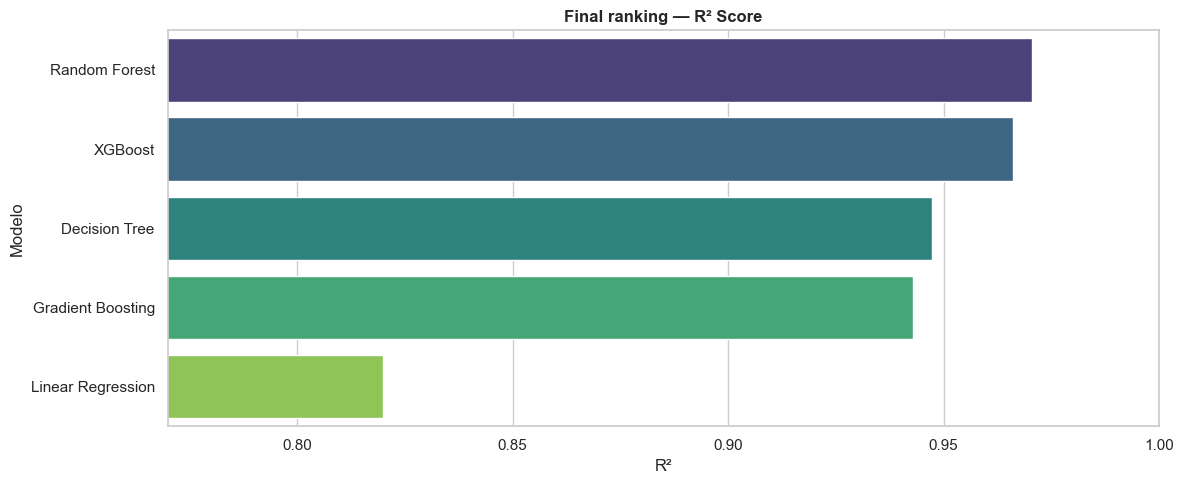


🥇 Tournament winner: Random Forest
   Baseline R²:  0.970452
   Baseline MAE: 11.51 kWh


In [16]:
modelos = {
    "Linear Regression":  LinearRegression(),
    "Decision Tree":      DecisionTreeRegressor(random_state=RANDOM_SEED),
    "Random Forest":      RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_SEED),
    "XGBoost":            XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,
                                       random_state=RANDOM_SEED, objective='reg:squarederror', n_jobs=-1),
}

resultados = []
print("🏟️ Tournament starting...\n")

for nombre, modelo in modelos.items():
    print(f"  Training {nombre}...")
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados.append({
        "Modelo": nombre,
        "MAE":    mean_absolute_error(y_test, pred),
        "RMSE":   np.sqrt(mean_squared_error(y_test, pred)),
        "R²":     r2_score(y_test, pred),
    })

df_resultados = pd.DataFrame(resultados).sort_values("R²", ascending=False)
print("\n🏆 Tournament ranking:")
print(df_resultados.to_string(index=False))

# Visualize ranking
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_resultados, x="R²", y="Modelo", palette="viridis", ax=ax)
ax.set_xlim(df_resultados["R²"].min() - 0.05, 1)
ax.set_title("Final ranking — R² Score", fontweight='bold')
plt.tight_layout()
plt.show()

mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
baseline_r2 = df_resultados.iloc[0]['R²']
baseline_mae = df_resultados.iloc[0]['MAE']
print(f"\n🥇 Tournament winner: {mejor_modelo_nombre}")
print(f"   Baseline R²:  {baseline_r2:.6f}")
print(f"   Baseline MAE: {baseline_mae:.2f} kWh")


## 4. Hyperparameter optimization with TimeSeriesSplit

Use proper temporal CV to avoid leaking future hours into training folds.


In [11]:
# Search space for XGBoost (the typical winner)
param_dist_xgb = {
    'n_estimators':  [100, 200, 300, 500],
    'max_depth':     [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

xgb_base = XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror', n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=5)

print("🔧 Optimizing XGBoost with TimeSeriesSplit (5 folds, 20 random configs)...")
buscador = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=tscv,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0,
)
buscador.fit(X_train, y_train)

xgb_optimizado = buscador.best_estimator_
predicciones_opt = xgb_optimizado.predict(X_test)

mae_opt = mean_absolute_error(y_test, predicciones_opt)
r2_opt  = r2_score(y_test, predicciones_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, predicciones_opt))

print("\n🏆 Optimization results:")
print(f"   Best params: {buscador.best_params_}")
print(f"\n   Optimized R²:   {r2_opt:.6f}  (baseline {baseline_r2:.6f})")
print(f"   Optimized MAE:  {mae_opt:.2f} kWh  (baseline {baseline_mae:.2f} kWh)")
print(f"   Optimized RMSE: {rmse_opt:.2f} kWh")


🔧 Optimizing XGBoost with TimeSeriesSplit (5 folds, 20 random configs)...

🏆 Optimization results:
   Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}

   Optimized R²:   0.971106  (baseline 0.970452)
   Optimized MAE:  11.50 kWh  (baseline 11.51 kWh)
   Optimized RMSE: 18.60 kWh


## 5. Save final model + test set for explainability notebook

In [12]:
# Save the model and the column order it expects
joblib.dump(xgb_optimizado, MODELS / 'best_model.pkl')
joblib.dump(list(X_train.columns), MODELS / 'training_columns.pkl')

# Save test data + predictions for next notebook
np.save(MODELS / 'X_test.npy', X_test.values)
np.save(MODELS / 'y_test.npy', y_test.values)
np.save(MODELS / 'predictions.npy', predicciones_opt)
joblib.dump(list(X_test.columns), MODELS / 'X_test_columns.pkl')

# Also save the full df_ml for clustering/anomaly notebooks
df_ml.to_csv(DATA_PROCESSED / 'df_ml_ready.csv', index=False)

print("✅ Model and test set persisted.")
print(f"   Best model:       {MODELS / 'best_model.pkl'}")
print(f"   Test features:    {MODELS / 'X_test.npy'}")
print(f"   ML-ready data:    {DATA_PROCESSED / 'df_ml_ready.csv'}")


✅ Model and test set persisted.
   Best model:       ..\outputs\models\best_model.pkl
   Test features:    ..\outputs\models\X_test.npy
   ML-ready data:    ..\data\processed\df_ml_ready.csv
